In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready!")

Ready!


In [2]:
cat_analysis = con.execute("""
    SELECT
        category_l1,
        COUNT(*)                            AS total_transactions,
        COUNT(DISTINCT user_id)             AS unique_buyers,
        ROUND(SUM(price), 2)                AS total_revenue,
        ROUND(AVG(price), 2)                AS avg_price,
        ROUND(SUM(price) / 1000000, 2)      AS revenue_millions,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS volume_share_pct,
        ROUND(SUM(price) * 100.0 / SUM(SUM(price)) OVER(), 2) AS revenue_share_pct
    FROM ecommerce_clean
    WHERE category_l1 != 'uncategorized'
    GROUP BY category_l1
    ORDER BY total_revenue DESC
""").df()

# Hitung gap: revenue_share - volume_share
# Positif = revenue lebih besar dari volume (high value)
# Negatif = volume lebih besar dari revenue (low value)
cat_analysis['revenue_volume_gap'] = (
    cat_analysis['revenue_share_pct'] - cat_analysis['volume_share_pct']
).round(2)

print("Revenue vs Volume Analysis:")
display(cat_analysis[['category_l1','volume_share_pct',
                       'revenue_share_pct','revenue_volume_gap',
                       'avg_price']])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Revenue vs Volume Analysis:


,category_l1,volume_share_pct,revenue_share_pct,revenue_volume_gap,avg_price
0,electronics,55.79,67.69,11.90,412.45
1,computers,8.03,11.93,3.90,504.91
2,appliances,17.17,11.30,-5.87,223.65
3,furniture,4.30,3.38,-0.92,267.20
4,auto,3.50,1.45,-2.05,141.02
5,apparel,5.32,1.28,-4.04,81.88
6,construction,2.53,1.22,-1.31,164.44
7,kids,1.80,0.85,-0.95,160.83
8,sport,0.61,0.70,0.09,387.92
9,accessories,0.82,0.15,-0.67,61.11


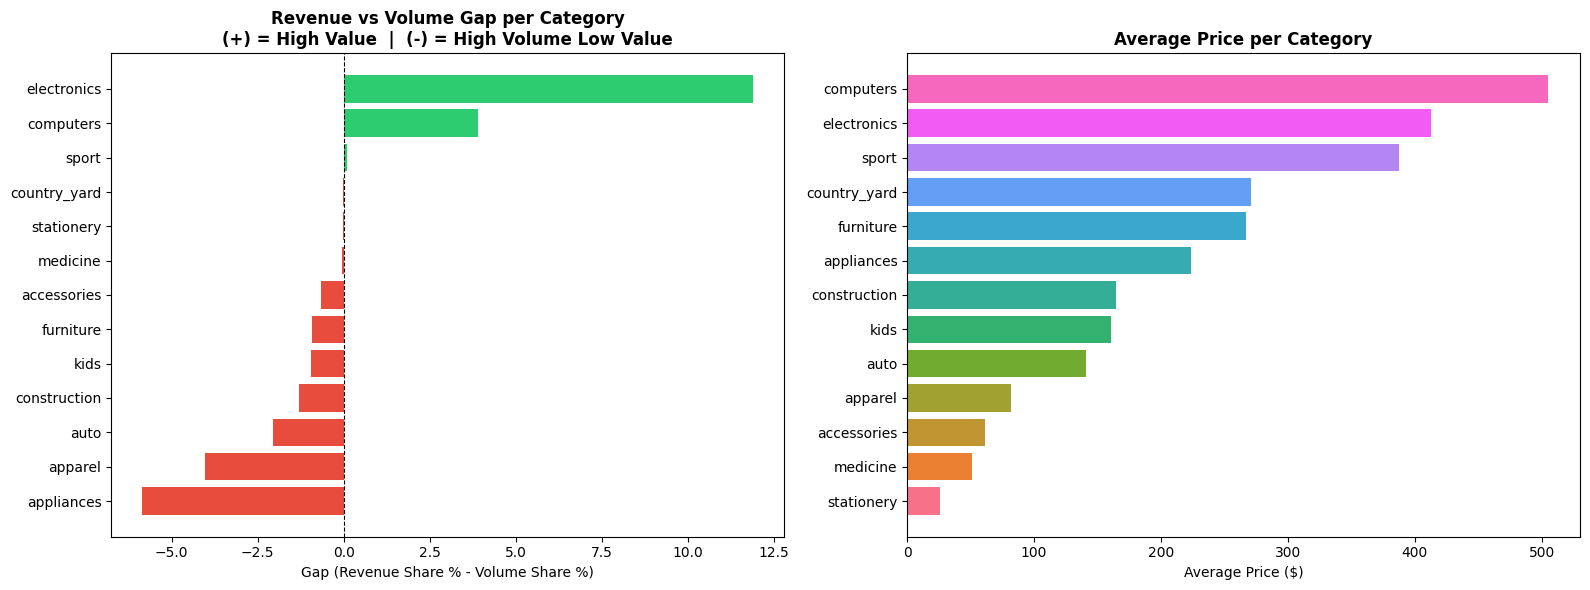

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by gap
gap_sorted = cat_analysis.sort_values('revenue_volume_gap', ascending=True)

# Warna: positif = hijau (high value), negatif = merah (low value)
colors = ['#2ecc71' if x > 0 else '#e74c3c' 
          for x in gap_sorted['revenue_volume_gap']]

# Chart 1 — Revenue vs Volume Gap
axes[0].barh(gap_sorted['category_l1'],
             gap_sorted['revenue_volume_gap'],
             color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Revenue vs Volume Gap per Category\n(+) = High Value  |  (-) = High Volume Low Value',
                  fontweight='bold')
axes[0].set_xlabel('Gap (Revenue Share % - Volume Share %)')

# Chart 2 — Avg Price per Category
price_sorted = cat_analysis.sort_values('avg_price', ascending=True)
axes[1].barh(price_sorted['category_l1'],
             price_sorted['avg_price'],
             color=sns.color_palette('husl', len(price_sorted)))
axes[1].set_title('Average Price per Category', fontweight='bold')
axes[1].set_xlabel('Average Price ($)')

plt.tight_layout()
plt.savefig('../reports/figures/08_revenue_volume_gap.png',
            dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

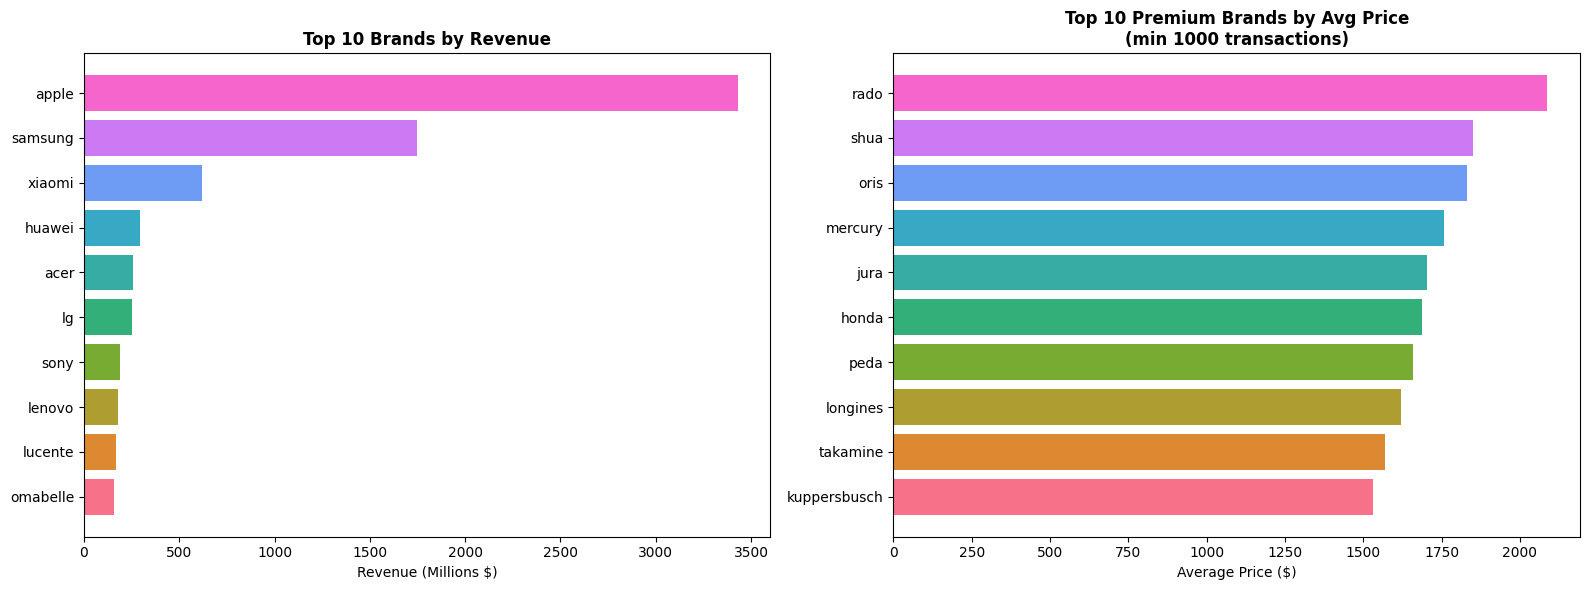


Top 10 Brands by Revenue:


,brand,total_transactions,unique_buyers,total_revenue,avg_price,revenue_millions
0,apple,4122554,729381,"3,430,705,076.80",832.18,"3,430.71"
1,samsung,5282774,935580,"1,745,036,641.26",330.33,"1,745.04"
2,xiaomi,3083763,470852,"618,166,439.72",200.46,618.17
3,huawei,1111205,234080,"294,001,131.25",264.58,294.00
4,acer,428153,87590,"258,642,888.30",604.09,258.64
5,lg,562404,145769,"253,976,654.54",451.59,253.98
6,sony,456644,122119,"191,478,148.77",419.32,191.48
7,lenovo,338103,69965,"181,140,628.08",535.76,181.14
8,lucente,655861,145495,"166,643,437.25",254.08,166.64
9,omabelle,112418,46050,"158,491,194.41","1,409.84",158.49


In [4]:
brand_analysis = con.execute("""
    SELECT
        brand,
        COUNT(*)                        AS total_transactions,
        COUNT(DISTINCT user_id)         AS unique_buyers,
        ROUND(SUM(price), 2)            AS total_revenue,
        ROUND(AVG(price), 2)            AS avg_price,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions
    FROM ecommerce_clean
    WHERE brand != 'unknown'
    GROUP BY brand
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('husl', 10)

# Chart 1 — Revenue
axes[0].barh(brand_analysis['brand'][::-1],
             brand_analysis['revenue_millions'][::-1],
             color=colors)
axes[0].set_title('Top 10 Brands by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (Millions $)')

# Chart 2 — Avg Price (Premium indicator)
brand_price = con.execute("""
    SELECT
        brand,
        ROUND(AVG(price), 2)    AS avg_price,
        COUNT(*)                AS total_transactions
    FROM ecommerce_clean
    WHERE brand != 'unknown'
    GROUP BY brand
    HAVING COUNT(*) > 1000
    ORDER BY avg_price DESC
    LIMIT 10
""").df()

axes[1].barh(brand_price['brand'][::-1],
             brand_price['avg_price'][::-1],
             color=colors)
axes[1].set_title('Top 10 Premium Brands by Avg Price\n(min 1000 transactions)',
                  fontweight='bold')
axes[1].set_xlabel('Average Price ($)')

plt.tight_layout()
plt.savefig('../reports/figures/09_brand_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Brands by Revenue:")
display(brand_analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

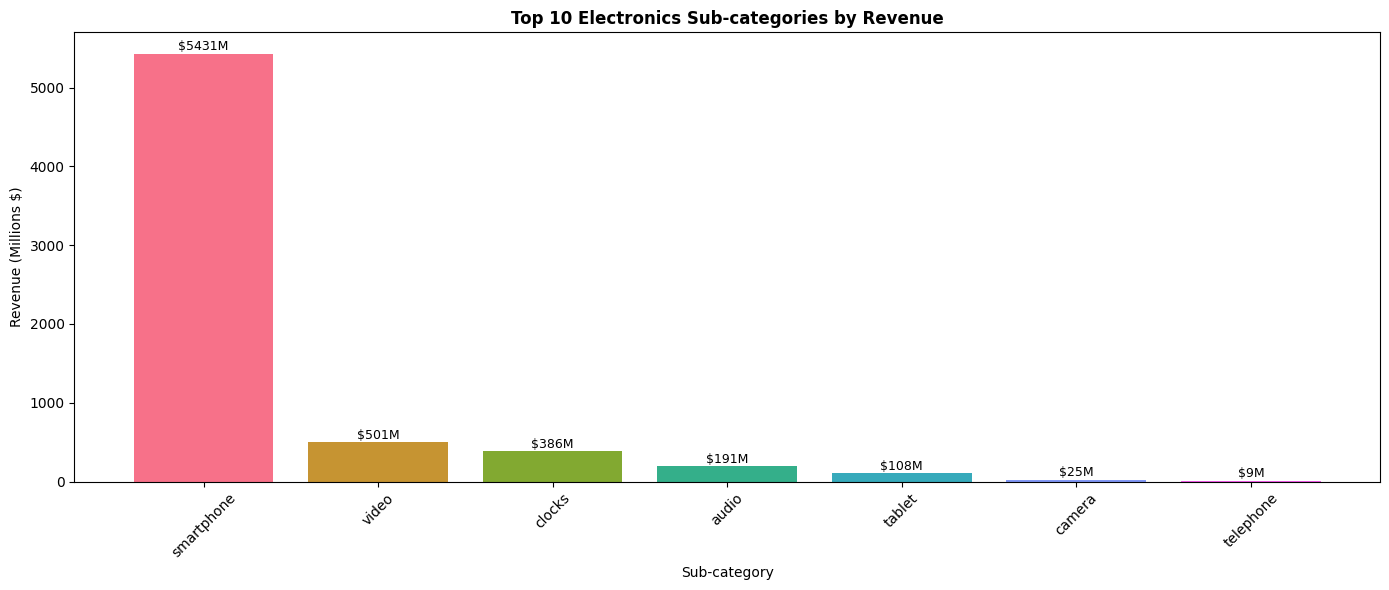


Electronics Sub-category Detail:


,category_l2,total_transactions,revenue_millions,avg_price,unique_buyers
0,smartphone,11502426,"5,430.80",472.14,1300114
1,video,1125860,500.90,444.91,172408
2,clocks,1307985,386.03,295.13,211804
3,audio,1573355,190.71,121.21,286013
4,tablet,316574,108.11,341.50,58729
5,camera,51308,25.04,487.98,12977
6,telephone,247397,9.10,36.79,47416


In [5]:
# Fokus ke electronics — kategori terbesar
subcat = con.execute("""
    SELECT
        category_l2,
        COUNT(*)                        AS total_transactions,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions,
        ROUND(AVG(price), 2)            AS avg_price,
        COUNT(DISTINCT user_id)         AS unique_buyers
    FROM ecommerce_clean
    WHERE category_l1 = 'electronics'
      AND category_l2 != ''
    GROUP BY category_l2
    ORDER BY revenue_millions DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(subcat['category_l2'],
              subcat['revenue_millions'],
              color=sns.color_palette('husl', len(subcat)))

# Tambah label nilai di atas bar
for bar, val in zip(bars, subcat['revenue_millions']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'${val:.0f}M',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Top 10 Electronics Sub-categories by Revenue',
             fontweight='bold')
ax.set_xlabel('Sub-category')
ax.set_ylabel('Revenue (Millions $)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/10_electronics_subcategory.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nElectronics Sub-category Detail:")
display(subcat)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

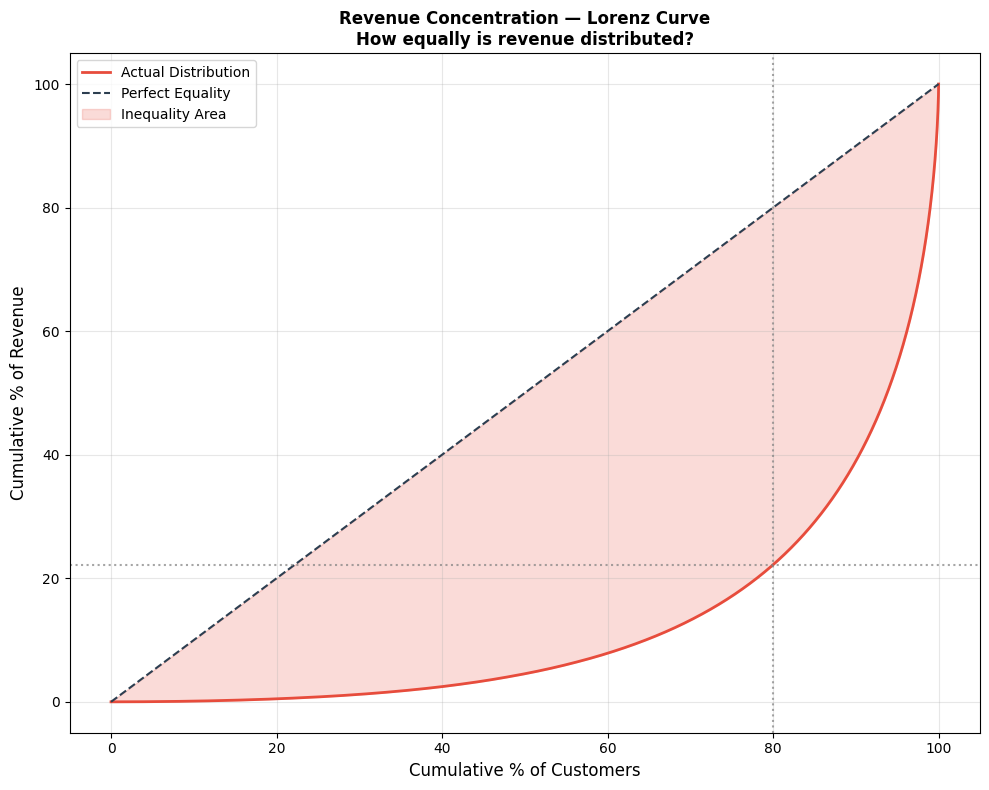


Key Finding:
   Top 1.0% customers
   generate 80% of total revenue


In [7]:
# Lorenz curve — visualisasi ketimpangan revenue antar user
user_rev = con.execute("""
    SELECT
        user_id,
        SUM(price) AS total_spending
    FROM ecommerce_clean
    GROUP BY user_id
    ORDER BY total_spending ASC
""").df()

# Hitung cumulative
user_rev['cum_spending'] = user_rev['total_spending'].cumsum()
user_rev['cum_pct_spending'] = user_rev['cum_spending'] / user_rev['total_spending'].sum() * 100
user_rev['cum_pct_users'] = (user_rev.index + 1) / len(user_rev) * 100

fig, ax = plt.subplots(figsize=(10, 8))

# Lorenz curve
ax.plot(user_rev['cum_pct_users'],
        user_rev['cum_pct_spending'],
        color='#e74c3c', linewidth=2,
        label='Actual Distribution')

# Garis equality (perfect equal distribution)
ax.plot([0, 100], [0, 100],
        color='#2c3e50', linewidth=1.5,
        linestyle='--', label='Perfect Equality')

# Shading area (Gini inequality)
ax.fill_between(user_rev['cum_pct_users'],
                user_rev['cum_pct_spending'],
                user_rev['cum_pct_users'],
                alpha=0.2, color='#e74c3c',
                label='Inequality Area')

# Annotasi 80/20
ax.axvline(80, color='gray', linestyle=':', alpha=0.7)
ax.axhline(user_rev[user_rev['cum_pct_users'] <= 80]
           ['cum_pct_spending'].max(),
           color='gray', linestyle=':', alpha=0.7)

ax.set_xlabel('Cumulative % of Customers', fontsize=12)
ax.set_ylabel('Cumulative % of Revenue', fontsize=12)
ax.set_title('Revenue Concentration — Lorenz Curve\nHow equally is revenue distributed?',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/11_lorenz_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Hitung berapa % top user menghasilkan 80% revenue
top_users = user_rev[user_rev['cum_pct_spending'] >= 80].iloc[0]
print(f"\nKey Finding:")
print(f"   Top {100 - top_users['cum_pct_users']:.1f}% customers")
print(f"   generate 80% of total revenue")

In [ ]:
con.close()
print("Revenue Analysis selesai!")
print("Charts saved:")
print("   08_revenue_volume_gap.png")
print("   09_brand_analysis.png")
print("   10_electronics_subcategory.png")
print("   11_lorenz_curve.png")